# 03. Baselines — Día 3

**Objetivo**: Entrenar 3 modelos baseline con parámetros default y compararlos en el set de test.

**Modelos**:
1. **Logistic Regression** — interpretable, requiere escalado
2. **Random Forest** — default + `class_weight='balanced'`
3. **XGBoost** — default, manejo nativo de NaN (aunque ya imputamos)

**Métricas**:
- AUC-ROC (principal)
- F1, Precision, Recall (clase positiva)
- Accuracy
- Confusion matrix

**Outputs**:
- `data/modelos/lr.pkl`, `rf.pkl`, `xgb.pkl`
- `figuras/dia_03_*.png`
- `data/resultados_baselines.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve
)
import xgboost as xgb

sns.set_style('whitegrid')
RAIZ_MODELO = Path('..').resolve()
DATA = RAIZ_MODELO / 'data'
FIGS = RAIZ_MODELO / 'figuras'
MODELOS = DATA / 'modelos'
MODELOS.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
print(f'sklearn, xgboost importados OK')

sklearn, xgboost importados OK


## 1. Cargar splits

In [2]:
X_train = pd.read_parquet(DATA / 'X_train.parquet')
X_test = pd.read_parquet(DATA / 'X_test.parquet')
y_train = pd.read_parquet(DATA / 'y_train.parquet').iloc[:, 0]
y_test = pd.read_parquet(DATA / 'y_test.parquet').iloc[:, 0]

print(f'X_train: {X_train.shape}  y_train pos%={y_train.mean()*100:.2f}%')
print(f'X_test:  {X_test.shape}   y_test  pos%={y_test.mean()*100:.2f}%')

X_train: (38664, 94)  y_train pos%=60.48%
X_test:  (9667, 94)   y_test  pos%=60.48%


## 2. Logistic Regression

Pipeline con StandardScaler. `class_weight='balanced'` para compensar el 60/40.

In [3]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1,
    )),
])

t0 = time.time()
lr.fit(X_train, y_train)
lr_train_time = time.time() - t0

lr_proba = lr.predict_proba(X_test)[:, 1]
lr_pred = (lr_proba >= 0.5).astype(int)

print(f'LR entrenado en {lr_train_time:.1f}s')
print(f'  AUC: {roc_auc_score(y_test, lr_proba):.4f}')
print(f'  F1:  {f1_score(y_test, lr_pred):.4f}')
print(f'  P:   {precision_score(y_test, lr_pred):.4f}')
print(f'  R:   {recall_score(y_test, lr_pred):.4f}')
print(f'  Acc: {accuracy_score(y_test, lr_pred):.4f}')

joblib.dump(lr, MODELOS / 'lr.pkl')

LR entrenado en 0.2s
  AUC: 0.8301
  F1:  0.7862
  P:   0.8186
  R:   0.7563
  Acc: 0.7512


['C:\\Users\\angel\\OneDrive\\Escritorio\\trabajo dirigido\\extraccion-datos\\modelo-predictivo-preliminar\\data\\modelos\\lr.pkl']

## 3. Random Forest

Default params + `class_weight='balanced'`.

In [4]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,         # full depth (default)
    min_samples_leaf=2,     # un poco de regularizacion
    n_jobs=-1,
    class_weight='balanced',
    random_state=RANDOM_STATE,
)

t0 = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - t0

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= 0.5).astype(int)

print(f'RF entrenado en {rf_train_time:.1f}s')
print(f'  AUC: {roc_auc_score(y_test, rf_proba):.4f}')
print(f'  F1:  {f1_score(y_test, rf_pred):.4f}')
print(f'  P:   {precision_score(y_test, rf_pred):.4f}')
print(f'  R:   {recall_score(y_test, rf_pred):.4f}')
print(f'  Acc: {accuracy_score(y_test, rf_pred):.4f}')

joblib.dump(rf, MODELOS / 'rf.pkl')

RF entrenado en 1.6s
  AUC: 0.8989
  F1:  0.8457
  P:   0.8500
  R:   0.8415
  Acc: 0.8143


['C:\\Users\\angel\\OneDrive\\Escritorio\\trabajo dirigido\\extraccion-datos\\modelo-predictivo-preliminar\\data\\modelos\\rf.pkl']

## 4. XGBoost

Default + `scale_pos_weight` para compensar el desbalance.

In [5]:
# scale_pos_weight = n_neg / n_pos
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {neg}/{pos} = {spw:.3f}')

xgbm = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=spw,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    tree_method='hist',
    enable_categorical=False,
)

t0 = time.time()
xgbm.fit(X_train, y_train)
xgb_train_time = time.time() - t0

xgb_proba = xgbm.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_proba >= 0.5).astype(int)

print(f'XGB entrenado en {xgb_train_time:.1f}s')
print(f'  AUC: {roc_auc_score(y_test, xgb_proba):.4f}')
print(f'  F1:  {f1_score(y_test, xgb_pred):.4f}')
print(f'  P:   {precision_score(y_test, xgb_pred):.4f}')
print(f'  R:   {recall_score(y_test, xgb_pred):.4f}')
print(f'  Acc: {accuracy_score(y_test, xgb_pred):.4f}')

joblib.dump(xgbm, MODELOS / 'xgb.pkl')

scale_pos_weight = 15279/23385 = 0.653


XGB entrenado en 0.8s
  AUC: 0.9015
  F1:  0.8421
  P:   0.8801
  R:   0.8073
  Acc: 0.8169


['C:\\Users\\angel\\OneDrive\\Escritorio\\trabajo dirigido\\extraccion-datos\\modelo-predictivo-preliminar\\data\\modelos\\xgb.pkl']

## 5. Comparativa

In [6]:
rows = []
for name, proba, pred, t_time in [
    ('LogisticRegression', lr_proba, lr_pred, lr_train_time),
    ('RandomForest', rf_proba, rf_pred, rf_train_time),
    ('XGBoost', xgb_proba, xgb_pred, xgb_train_time),
]:
    rows.append({
        'modelo': name,
        'AUC': roc_auc_score(y_test, proba),
        'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'Accuracy': accuracy_score(y_test, pred),
        'train_seg': t_time,
    })

resultados = pd.DataFrame(rows).round(4)
print(resultados.to_string(index=False))

resultados.to_csv(DATA / 'resultados_baselines.csv', index=False)
print(f'\nGuardado: data/resultados_baselines.csv')

            modelo    AUC     F1  Precision  Recall  Accuracy  train_seg
LogisticRegression 0.8301 0.7862     0.8186  0.7563    0.7512     0.2279
      RandomForest 0.8989 0.8457     0.8500  0.8415    0.8143     1.6360
           XGBoost 0.9015 0.8421     0.8801  0.8073    0.8169     0.8261

Guardado: data/resultados_baselines.csv


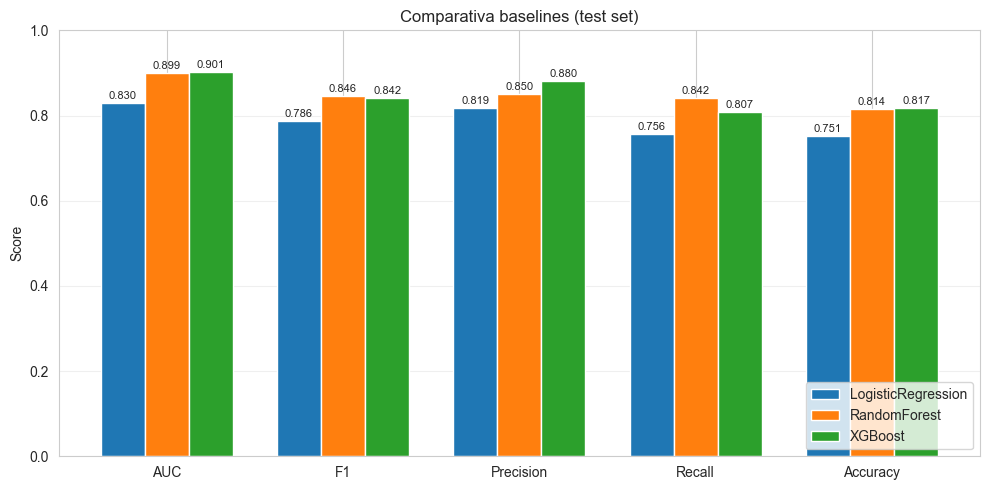

In [7]:
# Bar chart comparativo
fig, ax = plt.subplots(figsize=(10, 5))
metricas = ['AUC', 'F1', 'Precision', 'Recall', 'Accuracy']
x = np.arange(len(metricas))
width = 0.25

for i, modelo in enumerate(resultados['modelo']):
    valores = resultados.loc[resultados['modelo'] == modelo, metricas].values[0]
    bars = ax.bar(x + i * width, valores, width, label=modelo)
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v:.3f}',
                 ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metricas)
ax.set_ylabel('Score')
ax.set_title('Comparativa baselines (test set)')
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGS / 'dia_03_comparativa_baselines.png', dpi=120, bbox_inches='tight')
plt.show()

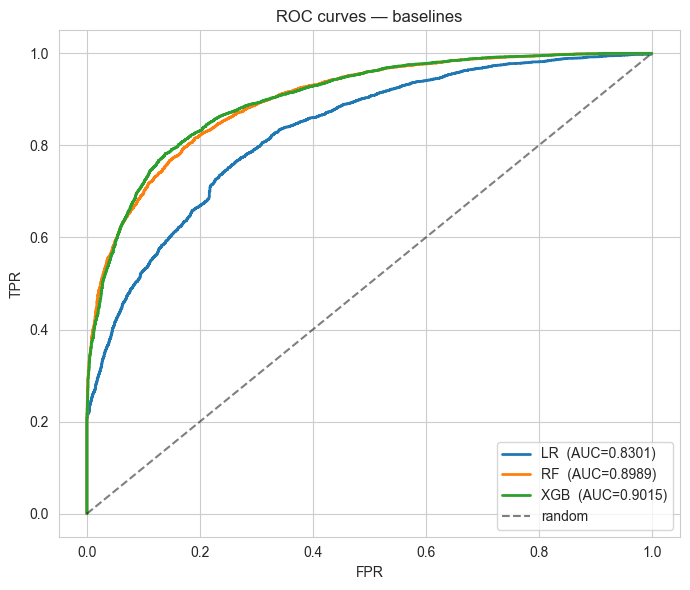

In [8]:
# Curvas ROC superpuestas
fig, ax = plt.subplots(figsize=(7, 6))
for name, proba in [('LR', lr_proba), ('RF', rf_proba), ('XGB', xgb_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name}  (AUC={auc:.4f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='random')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('ROC curves — baselines')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGS / 'dia_03_roc_baselines.png', dpi=120, bbox_inches='tight')
plt.show()

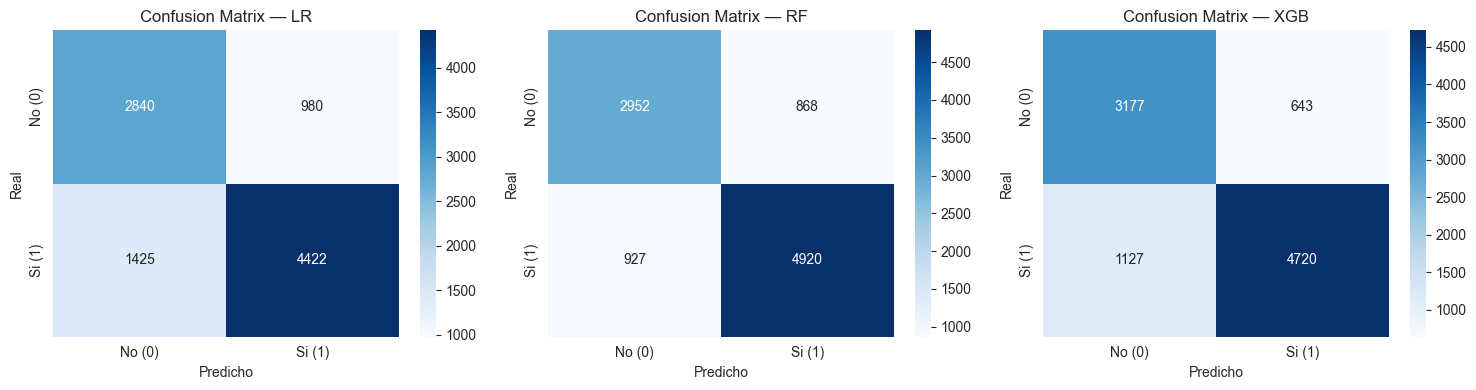

In [9]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, [
    ('LR', lr_pred), ('RF', rf_pred), ('XGB', xgb_pred)
]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No (0)', 'Si (1)'],
                yticklabels=['No (0)', 'Si (1)'])
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_title(f'Confusion Matrix — {name}')
plt.tight_layout()
plt.savefig(FIGS / 'dia_03_confusion_matrices.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
# Classification reports detallados
for name, pred in [('LogisticRegression', lr_pred), ('RandomForest', rf_pred), ('XGBoost', xgb_pred)]:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, pred, target_names=['No atraso (0)', 'Si atraso (1)']))


=== LogisticRegression ===
               precision    recall  f1-score   support

No atraso (0)       0.67      0.74      0.70      3820
Si atraso (1)       0.82      0.76      0.79      5847

     accuracy                           0.75      9667
    macro avg       0.74      0.75      0.74      9667
 weighted avg       0.76      0.75      0.75      9667


=== RandomForest ===
               precision    recall  f1-score   support

No atraso (0)       0.76      0.77      0.77      3820
Si atraso (1)       0.85      0.84      0.85      5847

     accuracy                           0.81      9667
    macro avg       0.81      0.81      0.81      9667
 weighted avg       0.81      0.81      0.81      9667


=== XGBoost ===
               precision    recall  f1-score   support

No atraso (0)       0.74      0.83      0.78      3820
Si atraso (1)       0.88      0.81      0.84      5847

     accuracy                           0.82      9667
    macro avg       0.81      0.82      0.81 

## Conclusiones del Día 3

Ver `data/resultados_baselines.csv` para los números exactos.

Los baselines establecen un piso de desempeño. El Día 4 introduce LightGBM y
análisis de feature importance. El Día 5 hace tuning sobre los top 2 modelos.

## Próximo (Día 4)

- LightGBM (alternativa a XGBoost)
- Feature importance (top 20)
- Comparativa con/sin features `pliego_*`
- Decisión: top 2 modelos para tuning